Импорт необходимых модулей:

In [301]:
import imp
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import os

import numpy as np
from PIL import Image 

from cmath import isclose
import math

import multiprocessing
from joblib import Parallel, delayed
# from math import isqrt

### Генерируем точки + строим графики и изображения

In [302]:
total_points_sqrt = 3163
total_points = total_points_sqrt * total_points_sqrt

print(total_points)

10004569


Запускаем генерацию точек

In [304]:
os.system("./ResearchGenerators --xs64 " + str(total_points) + " 0 1")
os.system("./ResearchGenerators --xs1024 " + str(total_points) + " 0 1")
os.system("./ResearchGenerators --mt19937 " + str(total_points) + " 0 1")

Elapsed time for generator: "xor-shift-64"; Total values: 10004569	 --- 3635146 microseconds
Elapsed time for generator: "xor-shift-1024"; Total values: 10004569	 --- 3547215 microseconds
Elapsed time for generator: "mt19937"; Total values: 10004569	 --- 3597091 microseconds


0

Подгружаем сгенерированные выборки:

In [305]:
x64      = pd.read_csv("xor_shift_64__sample.csv")
x1024    = pd.read_csv("xor_shift_1024__sample.csv")
mt19937  = pd.read_csv("mt19937__sample.csv")

Вывод первых 5-ти значий со сгенерированного файла:

In [306]:
x64.head()

,randoms
0,0.923063
1,0.936108
2,0.803757
3,0.817274
4,0.171244


Описательная статистика:

In [307]:
x64['randoms'].describe()

count    1.000457e+07
mean     4.998667e-01
std      2.886612e-01
min      7.252430e-08
25%      2.499080e-01
50%      4.997360e-01
75%      7.498200e-01
max      1.000000e+00
Name: randoms, dtype: float64

Строим гистограммы:

(9500.0, 10550.0)

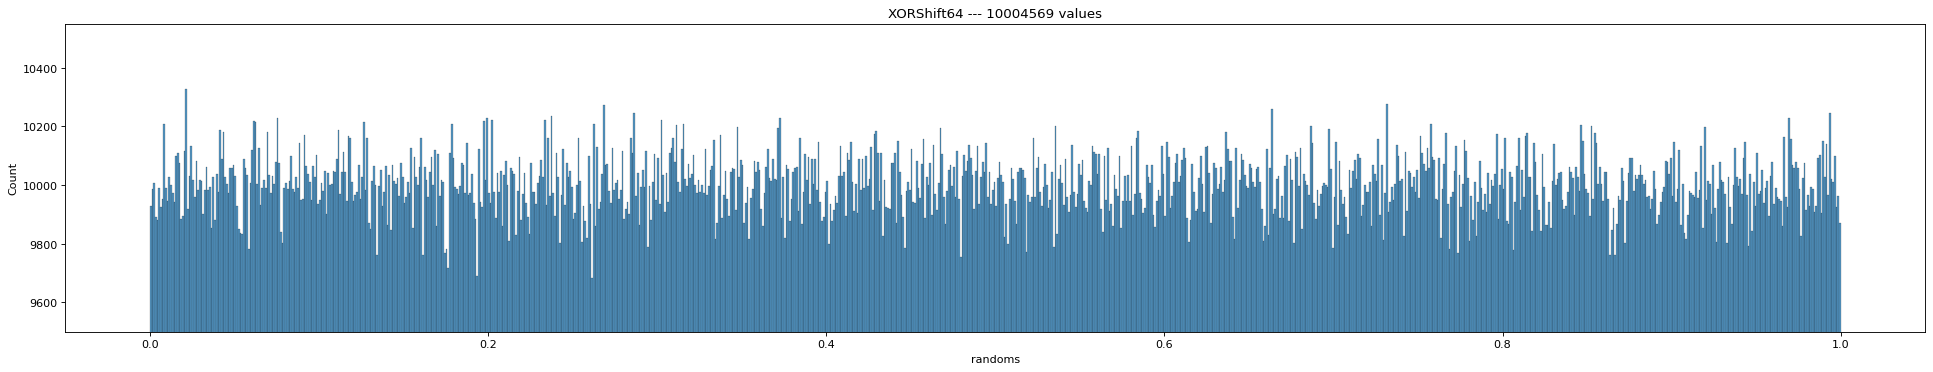

In [308]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x64, x="randoms", bins=1000).set(title='XORShift64 --- ' + str(total_points) + ' values')
plt.ylim(bottom=9500, top=10550)

In [309]:
data = 255 * np.array(x64)
data = np.uint8(data)

In [310]:
data.shape

(10004569, 1)

In [311]:
data = data.reshape(total_points_sqrt, total_points_sqrt)
print(data)

[[235 238 204 ... 103  45 161]
 [208  63  87 ...  63 200   0]
 [ 41 248 115 ...  88 214 206]
 ...
 [135 151   9 ... 247 178 119]
 [204 104  83 ...  17  81 226]
 [ 98 114  95 ... 149 198 158]]


In [312]:
data.shape

(3163, 3163)

In [313]:
img = Image.fromarray(data, 'L')
img.save('XORShift64_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9500.0, 10550.0)

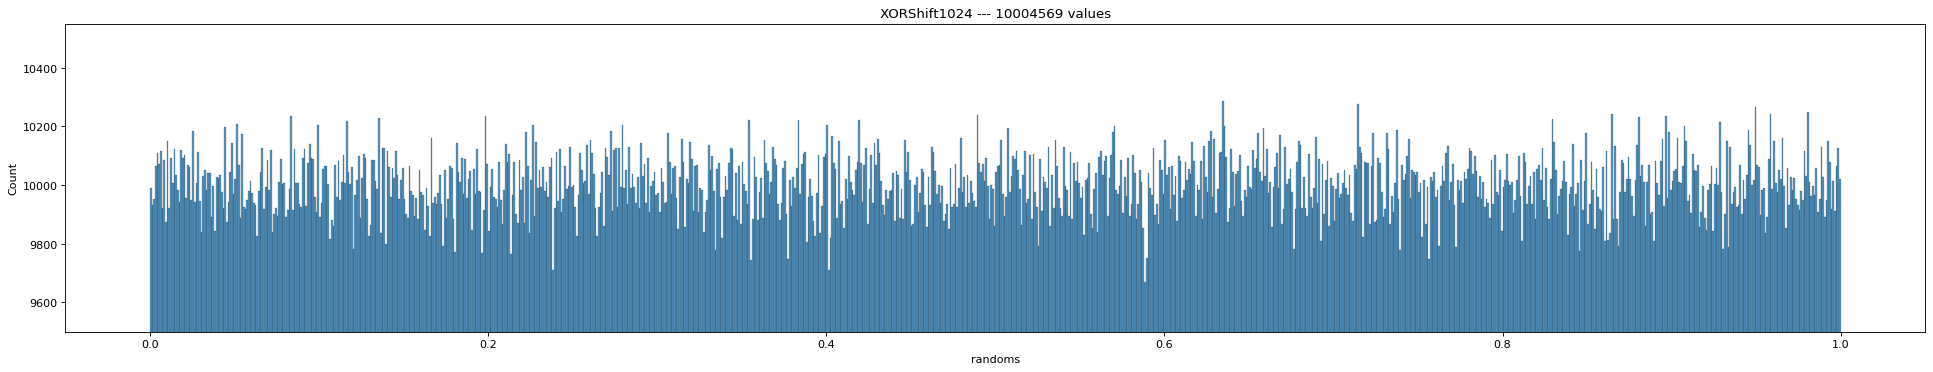

In [314]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=x1024, x="randoms", bins=1000).set(title='XORShift1024 --- ' + str(total_points) + ' values')
plt.ylim(bottom=9500, top=10550)

In [315]:
data = 255 * np.array(x1024)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [316]:
img = Image.fromarray(data, 'L')
img.save('XORShift1024_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

(9500.0, 10550.0)

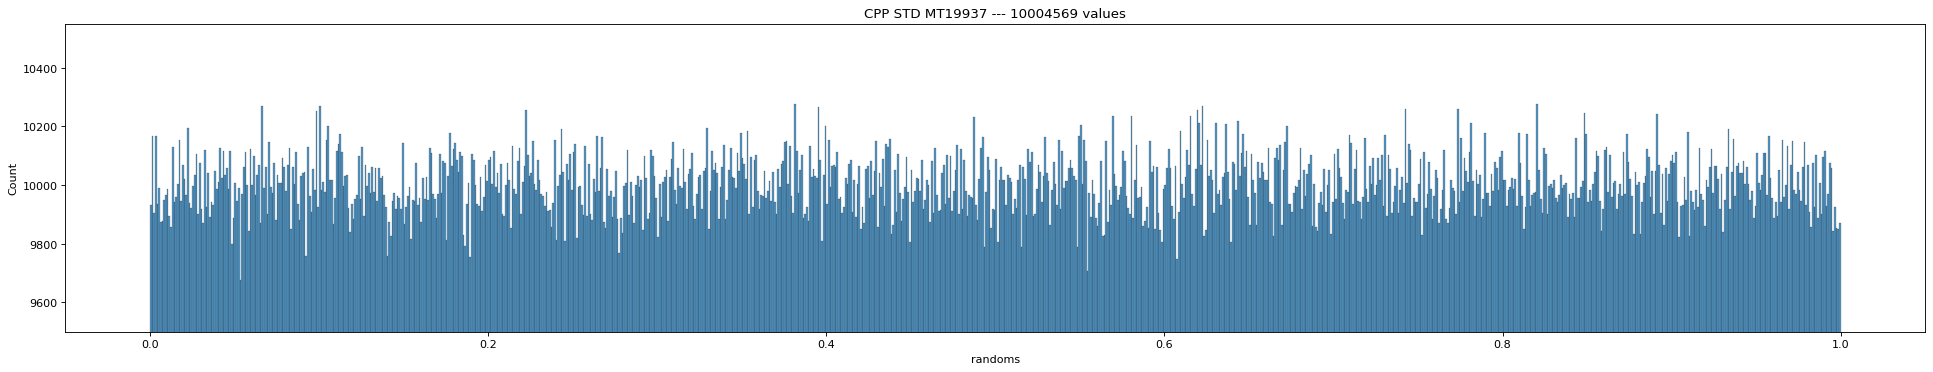

In [317]:
plt.figure(figsize=(30, 5), dpi=80)
sns.histplot(data=mt19937, x="randoms", bins=1000).set(title='CPP STD MT19937 --- ' + str(total_points) + ' values')
plt.ylim(bottom=9500, top=10550)

In [318]:
data = 255 * np.array(mt19937)
data = np.uint8(data)
data = data.reshape(total_points_sqrt, total_points_sqrt)

In [319]:
img = Image.fromarray(data, 'L')
img.save('MT19937_' + str(total_points) + '_values.png')

# раскомментировать для просмотра изображения
# display(img)

## Метрики качества

In [360]:
# метод проверки, что хотя бы одно сгенерированное число из выборки есть в диапазоне [left..right), 
# ИДЕАЛЬНЫЙ ГЕНЕРАТОР выдаст ОДНО ЧИСЛО на ОДИН ДИАПАЗОН
def parallel_task(left, step, generated_values):
    right = left + step # next элемент (правый сосед, как граница диапазона) из массива expected_values

    for generated in generated_values:
        if (isclose(generated, left) or generated > left) and generated < right:
            # если сгенерированное число (generated) >= левой границе диапазона (left) и строго меньше правой границы (right) ---> выдать единицу
            return 1
                    
    return 0

# метод проверки качества сгенерированных значений, два типа проверки 'by-sum' -- быстрее и 'by-element' -- медленнее (но точнее)
def get_quality_of_values(range_start=0, range_end=1, total_values=1000, algorithm='xs64', type='by-sum'):

    # массив ожидаемых значений [0..1) включительно с шагом 1/1000 по умолчанию
    range_step = (range_end - range_start) / total_values # рассчёт шага для нестандартного диапазона
    expected_values = np.arange(start=range_start, stop=range_end, step=range_step)    # ожидаемые значения ИДЕАЛЬНОГО ГЕНЕРАТОРА [0, 0.001, 0.002, ..., 1) по умолчанию

    os.system("make")
    generated_values = None

    # генерируем выборки, в зависимости от выбранного алгоритма
    if algorithm == 'xs64':
        os.system(f"release/executable --xs64 {total_values} {range_start} {range_end}")
        generated_values = pd.read_csv("xor_shift_64__sample.csv")

    elif algorithm == 'xs1024':
        os.system(f"release/executable --xs1024 {total_values} {range_start} {range_end}")
        generated_values = pd.read_csv("xor_shift_1024__sample.csv")

    elif algorithm == 'mt19937':
        os.system(f"release/executable --mt19937 {total_values} {range_start} {range_end}")
        generated_values = pd.read_csv("mt19937__sample.csv")

    else:
        raise ValueError("Wrong algorithm!")

    generated_values = generated_values.to_numpy()
    error = None

    print(f'Expected values: {expected_values}')
    print(f'Generated values: {generated_values}')

    # проверка схожести суммы идеальных значений с суммой реальных значений
    if type == 'by-sum':
        # по сумме
        ideal_sum = expected_values.sum()
        real_sum = generated_values.sum()

        # отклонение от необходимой суммы в процентах
        error = abs( ideal_sum - real_sum ) 
        error /= ideal_sum

    elif type == 'by-element':
        # по элементно

        # parallel loop
        num_cores = multiprocessing.cpu_count()
        results = Parallel(n_jobs=num_cores)(delayed(parallel_task)(ideal, range_step, generated_values) for ideal in expected_values)

        # реальное количество диапазонов, в которых есть сгенерированные числа (В ИДЕАЛЕ, это число будет равно КОЛИЧЕСТВУ СГЕНЕРИРОВАННЫХ ЧИСЕЛ)
        good_elements = np.array(results).sum()

        #for good in expected_values:
        #    for real in data:
        #        if math.isclose(good, real):
        #            good_elements += 1
        #            break
                
            #if number in data:
            #    good_elements += 1

        error = 1 - good_elements / total_values
        print(f'Good elements: {good_elements}')
        print(f'Total generated values: {total_values}\nError: {error}')

    else:
        raise ValueError("Wrong type!")

    return 1 - error    # вывод качества с учётом ошибки ---> 1 - идеальный генератор, 0 - плохой генератор

Параметры для проверки качества:

In [361]:
start = 0
end = 1

total = 10
type = 'by-element'

Метрика качества для XorShift64:

In [362]:
quality = get_quality_of_values(range_start=start, range_end=end, total_values=total, algorithm='xs64', type=type)
print(f'XorShift64 Quality: {quality}')

Elapsed time for generator: "xor-shift-64"; Total values: 10	 --- 190 microseconds
Expected values: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
Generated values: [[0.317865 ]
 [0.787832 ]
 [0.89882  ]
 [0.712196 ]
 [0.667261 ]
 [0.264769 ]
 [0.683554 ]
 [0.0836131]
 [0.636551 ]
 [0.929622 ]]
Good elements: 7
Total generated values: 10
Error: 0.30000000000000004
XorShift64 Quality: 0.7


Метрика качества для XorShift1024:

In [363]:
quality = get_quality_of_values(range_start=start, range_end=end, total_values=total, algorithm='xs1024', type=type)
print(f'XorShift1024 Quality: {quality}')

Elapsed time for generator: "xor-shift-1024"; Total values: 10	 --- 142 microseconds
Expected values: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
Generated values: [[0.154454 ]
 [0.372329 ]
 [0.51307  ]
 [0.922537 ]
 [0.435013 ]
 [0.0358592]
 [0.0884524]
 [0.921955 ]
 [0.591522 ]
 [0.154753 ]]
Good elements: 6
Total generated values: 10
Error: 0.4
XorShift1024 Quality: 0.6


Метрика качества для MT19937:

In [364]:
quality = get_quality_of_values(range_start=start, range_end=end, total_values=total, algorithm='mt19937', type=type)
print(f'MT19937 Quality: {quality}')

Elapsed time for generator: "mt19937"; Total values: 10	 --- 311 microseconds
Expected values: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9]
Generated values: [[0.143868]
 [0.905819]
 [0.777905]
 [0.165137]
 [0.634835]
 [0.234   ]
 [0.284765]
 [0.776293]
 [0.826029]
 [0.523546]]
Good elements: 7
Total generated values: 10
Error: 0.30000000000000004
MT19937 Quality: 0.7
